# The Treasury Auction Concession — a quantitative teardown 🔬
### 825 official auctions (1979→2026) · HAC event-dummy regression · era + size-detrended splits · a carry-clean TLT alpha test · costs × round trips · a planted-V synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Bigger auction bigger concession?: Busted](https://img.shields.io/badge/Bigger_auction_bigger_concession%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim (Lou-Yan-Zhang 2013; every rates desk since forever): yields **cheapen into** 10Y/30Y auctions and **richen after** — dealers demand a concession to warehouse anticipated supply. We test the two legs separately, then the size dose-response, then whether the richening was ever tradable net of costs.

> ⚠️ **Data note.** Auction records are the **complete official record** (FiscalData `auctions_query`, the TreasuryDirect feed; reopenings included) — no survivorship. Yields are constant-maturity indices (^TNX/^TYX); the tradable leg is TLT **total-return** with ^IRX as cash. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (as-of 2026-06-30, fingerprints `388e6555b83b` / `7d6a23aca7db`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from treasury_auction_concession import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    AU, YLDS, TLTF = data.load_real()
else:
    AU = YLDS = TLTF = None
print("real cache present:", HAVE_REAL,
      "| auctions:", (0 if AU is None else len(AU)),
      "| yield tape days:", (0 if YLDS is None else len(YLDS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'fp_yields': '388e6555b83b', 'fp_tlt': '7d6a23aca7db', 'n_auctions': 825, 'n_10y': 496, 'n_30y': 329, 'first': '1979-10-31', 'last': '2026-06-11', 'ten': {'10Y': (492, 1.55, -1.2, 0.0, 2.19, 0.324, 2.15, -0.283, -1.99), '30Y': (329, 2.18, -0.62, -0.49, 3.36, 0.548, 3.27, -0.08, -0.52)}, 'era': [('10Y', '1979-2007', 0.171, 0.53, -0.483, -1.77, 165), ('10Y', '2008-2019', 0.207, 0.97, -0.233, -1.06, 210), ('10Y', '2020-2026', 0.949, 3.39, 0.137, 0.44, 116), ('30Y', '1979-2007', 0.385, 0.8, -0.241, -0.63, 78), ('30Y', '2008-2019', 0.804, 3.86, -0.203, -0.94, 160), ('30Y', '2020-2026', 0.432, 1.41, 0.453, 1.52, 91)], 'size': {'10Y': (1.55, 308, 1.88, 180, -0.28, -1.2), '30Y': (2.25, 244, 0.9, 77, 0.92, -1.47)}, 'tlt': {'bh_excess': 3.01, 'alpha_base': -0.8, 'alpha_extra': 5.19, 't_alpha': 2.26, 'trips': 338, 'held': 38.5, 'per_trip': 30.0, 'cost': [(2.0, 4.25, 3.69, 2.11), (5.0, 4.25, 2.84, 1.63)], 'sub': [('2002-2019', 6.09, 5.54, 2.96, 236), ('2020-2026', -0.68, -1.32, -0.33, 102)]}, 'syn': [(0.0, -0.051, -0.29, -0.173, -1.04, 0.21, 0.14), (4.0, 0.749, 4.25, -0.973, -5.82, 8.35, 5.67)]}


real cache present: True | auctions: 825 | yield tape days: 16108


In [2]:
if HAVE_REAL:
    from quantlab import repro
    print(repro.data_stamp('^TNX/^TYX daily yields (%)', YLDS, asof=data.AS_OF))
    print(repro.data_stamp('TLT total-return close + ^IRX', TLTF, asof=data.AS_OF))
    print('auctions:', len(AU), dict(AU['tenor'].value_counts()))
else:
    print('cache missing — quoting docs/results.md (fingerprints', R['fp_yields'], '/', R['fp_tlt'], ')')

[data] ^TNX/^TYX daily yields (%): 16,108 rows  1962-01-02 -> 2026-06-26  as-of 2026-06-30  fingerprint=388e6555b83b


[data] TLT total-return close + ^IRX: 6,018 rows  2002-07-30 -> 2026-06-30  as-of 2026-06-30  fingerprint=7d6a23aca7db
auctions: 825 {'10Y': np.int64(496), '30Y': np.int64(329)}


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Cheapen-into leg REAL*: 10Y **+1.55 bps**/window, HAC **t = +2.15**; 30Y **+2.18 bps**, HAC **t = +3.27**. *Richen-after leg WEAK*: 10Y t = -1.99, 30Y t = -0.52 — under the bar, and sign-flipped post-2020. |
| **Tradability** | `FRAGILE` | Post-auction TLT round trip: net **+3.69%/yr** at 2 bps/leg (HAC t = +2.11), carry-clean alpha t = +2.26 — but **+5.54%/yr (t = 2.96)** in 2002-2019 vs **-1.32%/yr** since 2020, and t = 1.63 at 5 bps/leg. |
| **Size dose-response?** | `BUSTED` | Big vs small (detrended): Welch t = **-0.28** (10Y, wrong sign) and **+0.92** (30Y, n.s.). |

> 💡 In plain words: the market really does back up into auction week — but the fabled snap-back doesn't certify, the trade that harvested it died in 2020, and bigger prints don't get bigger discounts.

## 1 · The claim, steelmanned

Let $y_t$ be the constant-maturity yield (bps) and $A$ an auction day of the same tenor. Define the windows

$$\Delta y^{pre}_A = y_A - y_{A-5},\qquad \Delta y^{post}_A = y_{A+5} - y_A .$$

- **H₁ (concession).** $E[\Delta y^{pre}] > 0$ — dealers demand a discount to warehouse anticipated supply (Lou-Yan-Zhang's V, left leg).
- **H₂ (richening).** $E[\Delta y^{post}] < 0$ — the discount decays once the paper is placed (right leg), and it is harvestable via a duration ETF net of costs.
- **H₃ (dose-response).** Bigger auctions (relative to their own era) ⇒ bigger concessions — the mechanism's own scaling prediction.

We find **H₁ supported** on both tenors (HAC t = 2.15 / 3.27), **H₂ not certified** in yield space (t = −1.99 / −0.52; the TLT return-space version cleared until 2020, then died), **H₃ rejected** (Welch t = −0.28 / +0.92).

## 2 · So what? — why the test design matters

Three traps make naive versions of this study lie:

1. **Overlapping windows.** 10Y and 30Y auctions land in the same refunding week; 5-day windows overlap and daily yield changes autocorrelate. So the **primary** test is a daily dummy regression $\Delta y_t = \alpha + \beta_{pre} D^{pre}_t + \beta_{post} D^{post}_t + \varepsilon_t$ with **Newey-West** (8 lags ≈ one window width) — not a per-event t that pretends windows are i.i.d. The per-auction Welch vs ordinary weeks is reported as *supporting only* (rolling baseline windows overlap massively).
2. **Secular size growth.** Offerings grew ~20× since 1979 — a raw big/small split just compares eras. Size is detrended by the trailing median of the prior 8 same-tenor auctions.
3. **Carry masquerading as alpha.** TLT earns a positive unconditional term premium, so a positive round-trip mean could be beta. The alpha test regresses daily TLT **excess** returns on $D^{post}$ — the coefficient is the *extra* return of a post-auction day over an ordinary day.

## 3 · How we'd know — the protocol

- **Events.** All **825** 10Y/30Y auctions 1979-10-31 → 2026-06-11 (FiscalData `auctions_query`, `original_security_term` ∈ {10-Year, 30-Year}; reopenings kept — same supply event). **492** (10Y) and **329** (30Y) land on the yield tape with full ±5-day windows.
- **Windows.** Pre = 5 trading days ending **on the auction-day close** (1 pm results are inside it); post = the 5 after. Auction dates snapped to the last trading day ≤ date.
- **Primary inference.** HAC/Newey-West t on the dummy regression, per tenor.
- **Splits.** Eras declared up front (pre-2008 / 2008–2019 / 2020+); size detrended, median split, Welch.
- **Tradability.** Long TLT day A+1…A+5 (entry decided at close A — **one execution lag**, the calendar is public weeks ahead); merged overlapping windows; 2 and 5 bps one-way × NAV per leg; cash earns ^IRX; excess-vs-excess.
- **Positive control.** Deterministic random-walk world, synthetic auctions every 21 days, planted 4-bps-in / 4-bps-out V vs a zero-edge null.

## 4 · The teardown

### 4a · The two legs, on the full tape

The average cumulative yield path around auctions, and the HAC dummy regression that judges each leg.

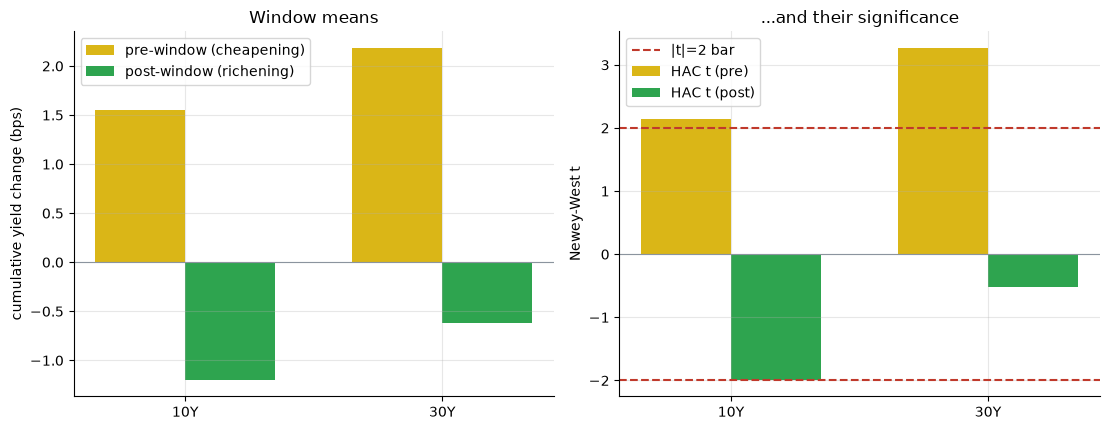

10Y: n=492  pre +1.55 bps (t=+2.15)  post -1.20 bps (t=-1.99)
30Y: n=329  pre +2.18 bps (t=+3.27)  post -0.62 bps (t=-0.52)


In [3]:
if HAVE_REAL:
    rows = []
    for tenor, col in [('10Y','y10'),('30Y','y30')]:
        s = st.summarize_tenor(YLDS[col], AU, tenor)
        r = s['reg']
        rows.append((tenor, s['n_auctions'], s['pre_mean_bps'], s['post_mean_bps'],
                     r['t_pre'], r['t_post']))
else:
    rows = [(k, v[0], v[1], v[2], v[6], v[8]) for k, v in R['ten'].items()]
x = np.arange(len(rows)); w = 0.35
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.2, 4.4))
a1.bar(x-w/2, [r[2] for r in rows], w, color=AMBER, label='pre-window (cheapening)')
a1.bar(x+w/2, [r[3] for r in rows], w, color=GREEN, label='post-window (richening)')
a1.set_xticks(x); a1.set_xticklabels([r[0] for r in rows]); a1.axhline(0, c=GREY, lw=.8)
a1.set_ylabel('cumulative yield change (bps)'); a1.set_title('Window means'); a1.legend()
a2.bar(x-w/2, [r[4] for r in rows], w, color=AMBER, label='HAC t (pre)')
a2.bar(x+w/2, [r[5] for r in rows], w, color=GREEN, label='HAC t (post)')
a2.axhline(2, ls='--', c=RED); a2.axhline(-2, ls='--', c=RED, label='|t|=2 bar')
a2.set_xticks(x); a2.set_xticklabels([r[0] for r in rows]); a2.axhline(0, c=GREY, lw=.8)
a2.set_ylabel('Newey-West t'); a2.set_title('...and their significance'); a2.legend()
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]}: n={r[1]}  pre {r[2]:+.2f} bps (t={r[4]:+.2f})  post {r[3]:+.2f} bps (t={r[5]:+.2f})')

> 💡 In plain words: the **left leg clears** on both tenors (10Y t = **+2.15**, 30Y t = **+3.27**) — a genuine ~1.5–3 bps concession per auction week. The **right leg doesn't**: 10Y t = -1.99 sits *just* under the bar and 30Y t = -0.52 is nowhere. `MIXED`, spelled out: **Real on the cheapen-into · Weak on the richen-after.**

### 4b · Era split — supply pressure moved the effect around

Eras declared up front (GFC/QE start 2008, pandemic deficits 2020) — descriptive cuts, not snooped breakpoints.

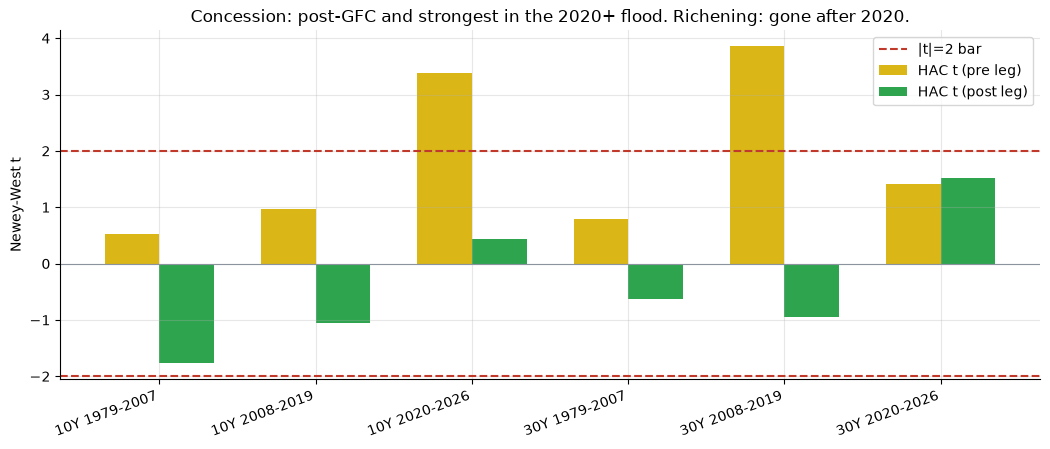

10Y 1979-2007: pre +0.171 bps/day (t=+0.53)  post -0.483 (t=-1.77)  n=165
10Y 2008-2019: pre +0.207 bps/day (t=+0.97)  post -0.233 (t=-1.06)  n=210
10Y 2020-2026: pre +0.949 bps/day (t=+3.39)  post +0.137 (t=+0.44)  n=116
30Y 1979-2007: pre +0.385 bps/day (t=+0.80)  post -0.241 (t=-0.63)  n=78
30Y 2008-2019: pre +0.804 bps/day (t=+3.86)  post -0.203 (t=-0.94)  n=160
30Y 2020-2026: pre +0.432 bps/day (t=+1.41)  post +0.453 (t=+1.52)  n=91


In [4]:
if HAVE_REAL:
    eras = []
    for tenor, col in [('10Y','y10'),('30Y','y30')]:
        for e in st.era_split(YLDS[col], AU.loc[AU['tenor']==tenor,'auction_date']):
            eras.append((tenor, e['era'], e['pre_bps_day'], e['t_pre'], e['post_bps_day'], e['t_post'], e['n_auctions']))
else:
    eras = R['era']
labels = [f'{t} {e}' for t,e,*_ in eras]
x = np.arange(len(eras)); w=.35
fig, ax = plt.subplots(figsize=(10.6, 4.6))
ax.bar(x-w/2, [r[3] for r in eras], w, color=AMBER, label='HAC t (pre leg)')
ax.bar(x+w/2, [r[5] for r in eras], w, color=GREEN, label='HAC t (post leg)')
ax.axhline(2, ls='--', c=RED); ax.axhline(-2, ls='--', c=RED, label='|t|=2 bar')
ax.axhline(0, c=GREY, lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Newey-West t'); ax.legend()
ax.set_title('Concession: post-GFC and strongest in the 2020+ flood. Richening: gone after 2020.')
plt.tight_layout(); plt.show()
for r in eras: print(f'{r[0]} {r[1]}: pre {r[2]:+.3f} bps/day (t={r[3]:+.2f})  post {r[4]:+.3f} (t={r[5]:+.2f})  n={r[6]}')

> 💡 In plain words: before 2008 there was barely any concession (t ≈ 0.5–0.8). It became decisive for the **30Y in the QE decade** (t = **3.86**) and for the **10Y in the 2020+ supply flood** (t = **3.39**, ~4.7 bps/week). Meanwhile the **post-leg flipped positive after 2020** on both tenors — yields now keep drifting up *after* auctions too. The concession grew; the mean-reversion died.

### 4c · The size dose-response (third axis)

If the mechanism is dealer risk-bearing capacity, more supply should buy more concession. Size = offering ÷ trailing median of the prior 8 same-tenor auctions; median split; Welch t on per-auction pre-window changes.

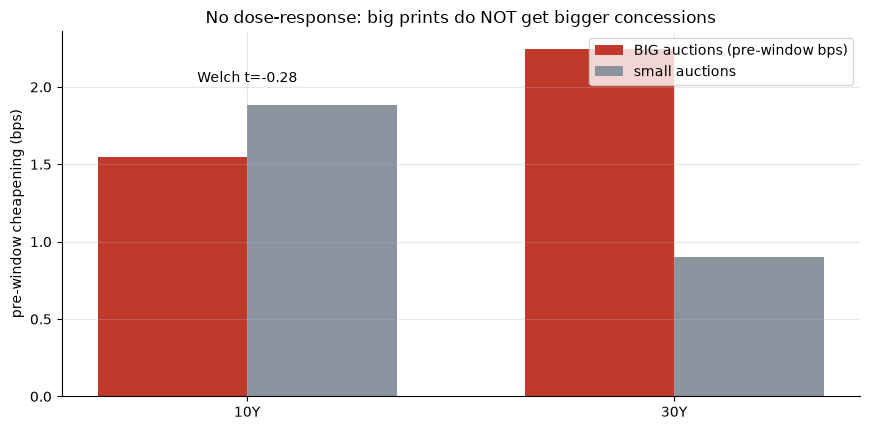

10Y: big +1.55 bps (n=308)  small +1.88 bps (n=180)  Welch t=-0.28
30Y: big +2.25 bps (n=244)  small +0.90 bps (n=77)  Welch t=+0.92


In [5]:
if HAVE_REAL:
    S = {t: st.size_split(AU, YLDS[c], t) for t, c in [('10Y','y10'),('30Y','y30')]}
    rows = [(t, S[t]['pre_big_bps'], S[t]['n_big'], S[t]['pre_small_bps'], S[t]['n_small'], S[t]['welch_t_pre']) for t in S]
else:
    rows = [(t, *R['size'][t][:5]) for t in R['size']]
x = np.arange(len(rows)); w=.35
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x-w/2, [r[1] for r in rows], w, color=RED, label='BIG auctions (pre-window bps)')
ax.bar(x+w/2, [r[3] for r in rows], w, color=GREY, label='small auctions')
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows])
for i,r in enumerate(rows): ax.annotate(f'Welch t={r[5]:+.2f}', (i, max(r[1],r[3])+.15), ha='center')
ax.set_ylabel('pre-window cheapening (bps)')
ax.set_title('No dose-response: big prints do NOT get bigger concessions')
ax.legend(); plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]}: big {r[1]:+.2f} bps (n={r[2]})  small {r[3]:+.2f} bps (n={r[4]})  Welch t={r[5]:+.2f}')

> 💡 In plain words: the 10Y points the **wrong way** (big +1.55 vs small +1.88 bps, Welch t = **-0.28**) and the 30Y points the right way but nowhere near the bar (t = **+0.92**). The concession is a *calendar* habit — the market clears its throat before every auction, big or small. **BUSTED.**

### 4d · Tradability — the post-auction TLT round trip

Entry at the auction-day close (one lag), hold 5 days, merged windows, excess of bills, costs per leg. Plus the carry-clean alpha regression (is a post-auction day *abnormally* good, beyond TLT's unconditional carry?).

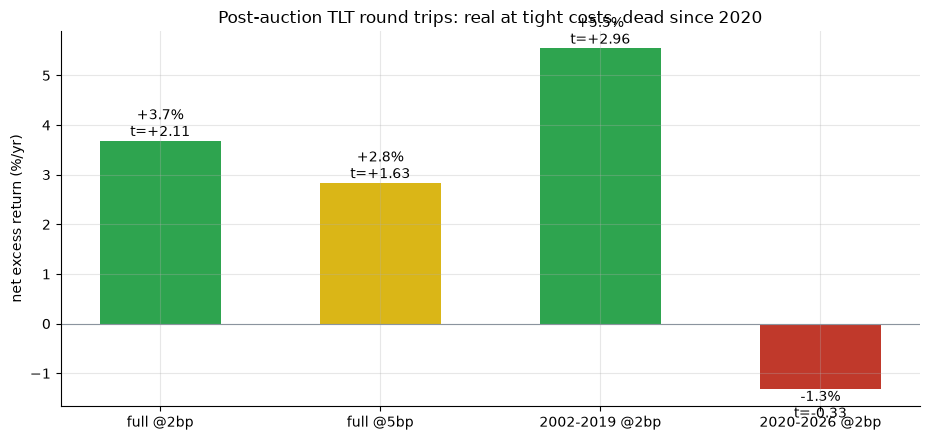

alpha reg: ordinary day -0.80 bps/day, post-auction extra +5.19 bps/day (t=+2.26); TLT B&H excess +3.01%/yr
full @2bp: net +3.69%/yr  HAC t=+2.11
full @5bp: net +2.84%/yr  HAC t=+1.63
2002-2019 @2bp: net +5.54%/yr  HAC t=+2.96
2020-2026 @2bp: net -1.32%/yr  HAC t=-0.33


In [6]:
if HAVE_REAL:
    al = st.tlt_post_alpha(TLTF, AU['auction_date'])
    trs = {cb: st.tlt_post_auction(TLTF, AU['auction_date'], cost_bps=cb) for cb in (2.0, 5.0)}
    t1 = TLTF[TLTF.index <= '2019-12-31']; d1 = AU.loc[AU['auction_date'] <= '2019-12-31','auction_date']
    t2 = TLTF[TLTF.index >= '2020-01-01']; d2 = AU.loc[AU['auction_date'] >= '2020-01-01','auction_date']
    subs = [('2002-2019', st.tlt_post_auction(t1, d1, cost_bps=2.0)),
            ('2020-2026', st.tlt_post_auction(t2, d2, cost_bps=2.0))]
    bars = [('full @2bp', trs[2.0]['net_ann_pct'], trs[2.0]['t_net_held']),
            ('full @5bp', trs[5.0]['net_ann_pct'], trs[5.0]['t_net_held']),
            ('2002-2019 @2bp', subs[0][1]['net_ann_pct'], subs[0][1]['t_net_held']),
            ('2020-2026 @2bp', subs[1][1]['net_ann_pct'], subs[1][1]['t_net_held'])]
    alpha_line = (al['base_bps_day'], al['post_extra_bps_day'], al['t_post_extra'], al['bh_excess_ann_pct'])
else:
    bars = [('full @2bp', R['tlt']['cost'][0][2], R['tlt']['cost'][0][3]),
            ('full @5bp', R['tlt']['cost'][1][2], R['tlt']['cost'][1][3]),
            ('2002-2019 @2bp', R['tlt']['sub'][0][2], R['tlt']['sub'][0][3]),
            ('2020-2026 @2bp', R['tlt']['sub'][1][2], R['tlt']['sub'][1][3])]
    alpha_line = (R['tlt']['alpha_base'], R['tlt']['alpha_extra'], R['tlt']['t_alpha'], R['tlt']['bh_excess'])
fig, ax = plt.subplots(figsize=(9.4, 4.5))
colors = [GREEN if b[2] >= 2 else (RED if b[1] < 0 else AMBER) for b in bars]
ax.bar([b[0] for b in bars], [b[1] for b in bars], color=colors, width=.55)
ax.axhline(0, c=GREY, lw=.8)
for i,b in enumerate(bars): ax.annotate(f'{b[1]:+.1f}%\nt={b[2]:+.2f}', (i, b[1]), ha='center', va='bottom' if b[1]>=0 else 'top')
ax.set_ylabel('net excess return (%/yr)')
ax.set_title('Post-auction TLT round trips: real at tight costs, dead since 2020')
plt.tight_layout(); plt.show()
print(f'alpha reg: ordinary day {alpha_line[0]:+.2f} bps/day, post-auction extra {alpha_line[1]:+.2f} bps/day (t={alpha_line[2]:+.2f}); TLT B&H excess {alpha_line[3]:+.2f}%/yr')
for b in bars: print(f'{b[0]}: net {b[1]:+.2f}%/yr  HAC t={b[2]:+.2f}')

> 💡 In plain words: on the full tape the trade clears at tight costs (net **+3.69%/yr**, t = **+2.11**; and the alpha regression says post-auction days really were **+5.2 bps/day** better than ordinary days, t = **+2.26** — not just carry, since TLT's unconditional excess is only 3.0%/yr at 100% exposure vs this at 38.5%). But it is a **2002–2019 phenomenon** (t = 2.96) that has been **negative since 2020** (-1.3%/yr), and 5 bps/leg already drops it under the bar (t = 1.63). Real once — **FRAGILE** now.

### 4e · Faithful-engine & power control — we know the truth here

A deterministic random-walk yield world with synthetic auctions every 21 trading days. Null: no planted effect — the detector must stay quiet. Plant: 4 bps of cheapening in, 4 bps of richening out — it must light up, and the fund trade must bank it.

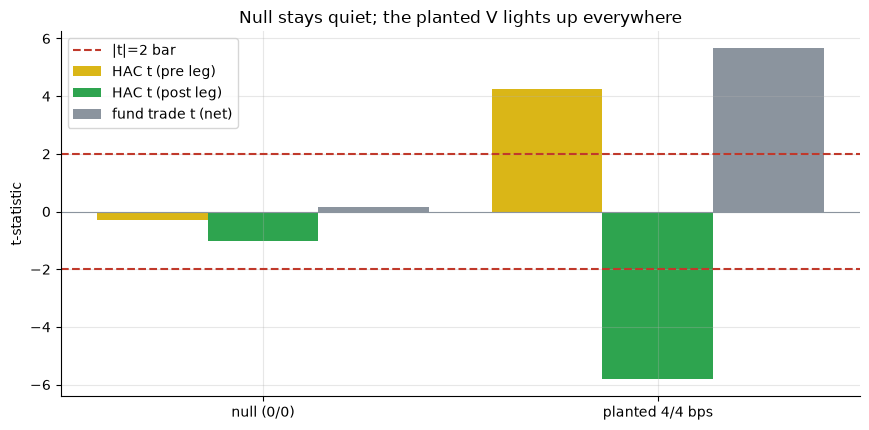

null (0/0): t_pre=-0.29  t_post=-1.04  fund net +0.21%/yr (t=+0.14)
planted 4/4 bps: t_pre=+4.25  t_post=-5.82  fund net +8.35%/yr (t=+5.67)


In [7]:
res = []
for c, r_, label in [(0.0, 0.0, 'null (0/0)'), (4.0, 4.0, 'planted 4/4 bps')]:
    au_s, y_s, tlt_s = data.synthetic_world(concession_bps=c, richen_bps=r_, seed=603)
    reg = st.dummy_regression(y_s['y10'], au_s['auction_date'])
    tr = st.tlt_post_auction(tlt_s, au_s['auction_date'], cost_bps=2.0)
    res.append((label, reg['t_pre'], reg['t_post'], tr['net_ann_pct'], tr['t_net_held']))
x = np.arange(len(res)); w=.28
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(x-w, [r[1] for r in res], w, color=AMBER, label='HAC t (pre leg)')
ax.bar(x,   [r[2] for r in res], w, color=GREEN, label='HAC t (post leg)')
ax.bar(x+w, [r[4] for r in res], w, color=GREY, label='fund trade t (net)')
ax.axhline(2, ls='--', c=RED); ax.axhline(-2, ls='--', c=RED, label='|t|=2 bar')
ax.axhline(0, c=GREY, lw=.8)
ax.set_xticks(x); ax.set_xticklabels([r[0] for r in res])
ax.set_ylabel('t-statistic'); ax.set_title('Null stays quiet; the planted V lights up everywhere')
ax.legend(); plt.tight_layout(); plt.show()
for r in res: print(f'{r[0]}: t_pre={r[1]:+.2f}  t_post={r[2]:+.2f}  fund net {r[3]:+.2f}%/yr (t={r[4]:+.2f})')

> 💡 In plain words: with nothing planted the machinery reads t = **-0.29 / -1.04** (quiet); with a 4-bps V it reads **+4.25 / -5.82** and the fund banks **+8.35%/yr** (t = +5.67). The real-tape t-stats are measurements, not construction artefacts. *(A faithful-engine / power check only — never cited in support of the real-tape stamps.)*

## 5 · The verdict

- **Signal `MIXED`** — *Real on the cheapen-into leg*: 10Y **+1.55 bps**/window (HAC t = **+2.15**), 30Y **+2.18 bps** (t = **+3.27**), strongest exactly where the supply story says (10Y 2020+ t = 3.39; 30Y 2008-2019 t = 3.86). *Weak on the richen-after leg*: 10Y t = -1.99, 30Y t = -0.52, sign-flipped post-2020. No survivorship (official complete record, constant-maturity indices).
- **Tradability `FRAGILE`** — post-auction TLT: net +3.69%/yr at 2 bps/leg (t = +2.11), alpha t = +2.26; but 2002-2019 t = 2.96 vs 2020+ net -1.32%/yr, and t = 1.63 at 5 bps/leg. Real, then decayed. Not INVESTABLE.
- **Size dose-response `BUSTED`** — Welch t = -0.28 (10Y, wrong sign) / +0.92 (30Y, n.s.). The concession follows the calendar, not the print size.

## 6 · Going further

- **Intraday would sharpen both legs.** Lou-Yan-Zhang find part of the reversal happens within days of the auction close; daily closes blur it. A tick-level replication (BrokerTec / futures) is the natural upgrade — the daily tape is the honest retail-visible version.
- **The 2020 regime break is the live question.** Concession up, mean-reversion gone: consistent with dealer balance-sheet caps binding *permanently* rather than episodically. Treasury buybacks (2024→) are a natural experiment to watch.
- **Different plumbing, different studies:** [382-treasury-basis-trade](../../382-treasury-basis-trade/README.md) (cash-futures basis), [383-sofr-repo-stress](../../383-sofr-repo-stress/README.md) (repo spikes), [380-curve-roll-down](../../380-curve-roll-down/README.md) (static roll-down).

*The reproducible core is offline and deterministic; the signal is the public auction calendar, the myth-check is the size dose-response. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*